# **Machine Learning - Lựa chọn mô hình học máy tối ưu**

**Mục tiêu:**
- Áp dụng nhiều mô hình machine learning khác nhau (ngoài LightGBM đã tối ưu trước đó) để dự báo doanh thu.
- So sánh hiệu quả các mô hình trên cùng bộ dữ liệu đã xử lý.
- Tất cả hàm train và tối ưu đều được xây dựng trong module `src/ml.py`.
- Đánh giá dựa trên các chỉ số: MAE, RMSE, MAPE, R2.

**Baseline LightGBM đã tối ưu trước đó: MAPE = 18,14%**

## Mục lục
1. [Thiết lập và chuẩn bị dữ liệu](#1)
2. [Huấn luyện và đánh giá các mô hình](#2)
3. [So sánh kết quả các mô hình](#3)
4. [Kết luận & Khuyến nghị](#4)

In [4]:
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath('..'))
from src.get_data import get_data_processed
from src.ml import run_all_models, run_single_model

In [5]:
df = get_data_processed("final_features.csv")
df.head()

Đã đọc thành công dữ liệu từ: D:\datathon\vimchanhxa-datathon\data\processed\final_features.csv


,date,revenue,cogs,is_test,order_count,unique_customers,total_quantity,day_of_week,day_of_month,day_of_year,...,year,is_weekend,days_since_start,is_payday,is_double_day,days_to_tet,is_pre_tet_rush,is_tet_holiday,is_promo,total_discount
0,2012-07-04,5123547.94,3982991.19,0,162.0,161.0,777.0,2,4,186,...,2012,0,0,1,0,-163,0,0,0,0.0
1,2012-07-05,2751773.45,2150580.23,0,97.0,97.0,428.0,3,5,187,...,2012,0,1,1,0,-164,0,0,0,0.0
2,2012-07-06,3054029.42,2517632.84,0,93.0,93.0,441.0,4,6,188,...,2012,0,2,0,0,-165,0,0,0,0.0
3,2012-07-07,2667930.94,2108246.62,0,73.0,73.0,364.0,5,7,189,...,2012,1,3,0,1,-166,0,0,0,0.0
4,2012-07-08,2360851.90,1808622.79,0,88.0,87.0,394.0,6,8,190,...,2012,1,4,0,0,-167,0,0,0,0.0


## 2. Huấn luyện và đánh giá các mô hình
Để tìm ra mô hình tốt nhất cho bài toán cũng như bộ dữ liệu features của chúng tôi, chúng tôi đã tổng hợp lại một vài mô hình phổ biến nhất với `random_seed = 42` và những thông số cơ bản cho các mô hình. Điều này giúp tôi đánh giá công bằng được mô hình nào tốt nhất hiện tại và sẽ được sử dụng để tối ưu. Dưới đây là danh sách các models của chúng tôi
- Linear:
    - LinearRegression
    - Ridge
    - Lasso
    - ElasticNet
    - BayesianRidge
    - HuberRegressor
- Tree:
    - DecisionTree
    - RandomForest
    - ExtraTrees
- Boosting (sklearn):
    - HistGradientBoosting
    - AdaBoost
- External Boosting
    - XGBoost
    - CatBoost
    - LightGBM
    - LightGBM_DART

Tất cả models sẽ được đánh giá dựa trên 4 tiêu chí sau: `MAE`, `RMSE`, `MAPE` và `R-squared` 

In [3]:
target = 'revenue'
features = [col for col in df.columns if col not in ['date', 'cogs', 'is_test', 'order_count', 'unique_customers', 'total_quantity', target]]

evaluate_models = run_all_models(df, target=target, features=features)
evaluate_models

Done: LinearRegression
Done: Ridge
Done: Lasso
Done: ElasticNet
Done: BayesianRidge
Done: HuberRegressor
Done: DecisionTree
Done: RandomForest
Done: ExtraTrees
Done: HistGradientBoosting
Done: AdaBoost
Done: LightGBM
Done: LightGBM_DART
Done: XGBoost
Done: CatBoost


,Model,MAE,RMSE,MAPE,R-squared
0,CatBoost,5.421894e+05,7.625633e+05,18.009269,0.792442
1,XGBoost,5.616388e+05,7.677606e+05,19.561567,0.789603
2,LightGBM,5.904414e+05,8.095604e+05,20.028097,0.766070
3,HistGradientBoosting,6.025878e+05,8.213319e+05,20.220865,0.759217
4,RandomForest,6.363284e+05,8.897243e+05,21.138095,0.717448
5,ExtraTrees,6.640357e+05,9.135288e+05,22.427056,0.702126
6,LightGBM_DART,7.187371e+05,9.748992e+05,22.233282,0.660760
7,DecisionTree,7.717408e+05,1.082402e+06,25.554985,0.581818
8,BayesianRidge,8.916997e+05,1.237642e+06,36.216165,0.453264
9,LinearRegression,8.982507e+05,1.243098e+06,35.277134,0.448433


In [4]:
val_result, model, metrics = run_single_model(model_name='CatBoost', df=df, target=target, features=features)

print("Metrics:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value}")

Metrics:
MAE: 542189.3956462385
RMSE: 762563.2802912166
MAPE: 18.00926879607106
R-squared: 0.7924419854077848


In [5]:
val_result.head()

,date,revenue,day_of_week,day_of_month,day_of_year,month,year,is_weekend,days_since_start,is_payday,is_double_day,days_to_tet,is_pre_tet_rush,is_tet_holiday,is_promo,total_discount,prediction
3468,2022-01-01,2932155.47,5,1,1,1,2022,1,3468,1,1,31,0,0,1,20.0,2.288710e+06
3469,2022-01-02,2361965.00,6,2,2,1,2022,1,3469,1,0,30,0,0,1,20.0,1.494068e+06
3470,2022-01-03,545563.72,0,3,3,1,2022,0,3470,1,0,29,0,0,0,0.0,6.134484e+05
3471,2022-01-04,1242319.38,1,4,4,1,2022,0,3471,1,0,28,0,0,0,0.0,8.443911e+05
3472,2022-01-05,809977.60,2,5,5,1,2022,0,3472,1,0,27,0,0,0,0.0,8.623731e+05


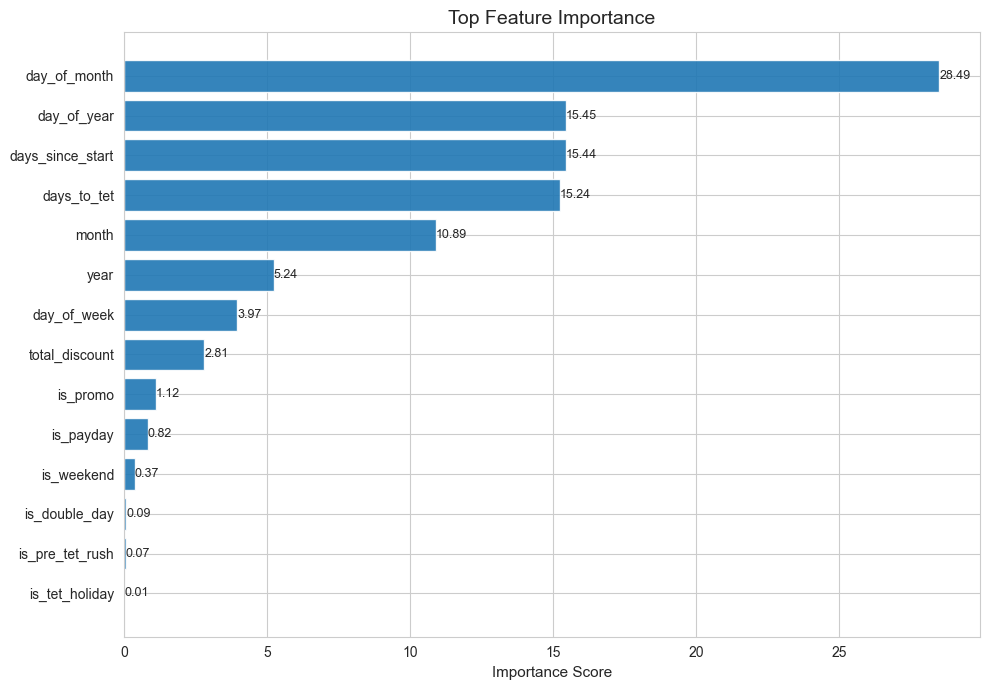

In [6]:
from src.visualization import *
plot_feature_importance(model, features)

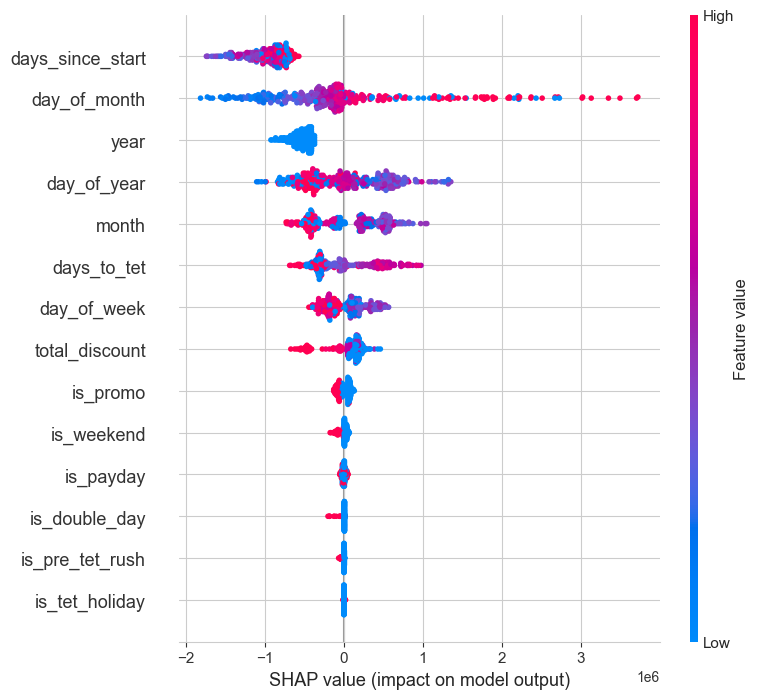

In [7]:
plot_shap_summary(model, val_result, features)

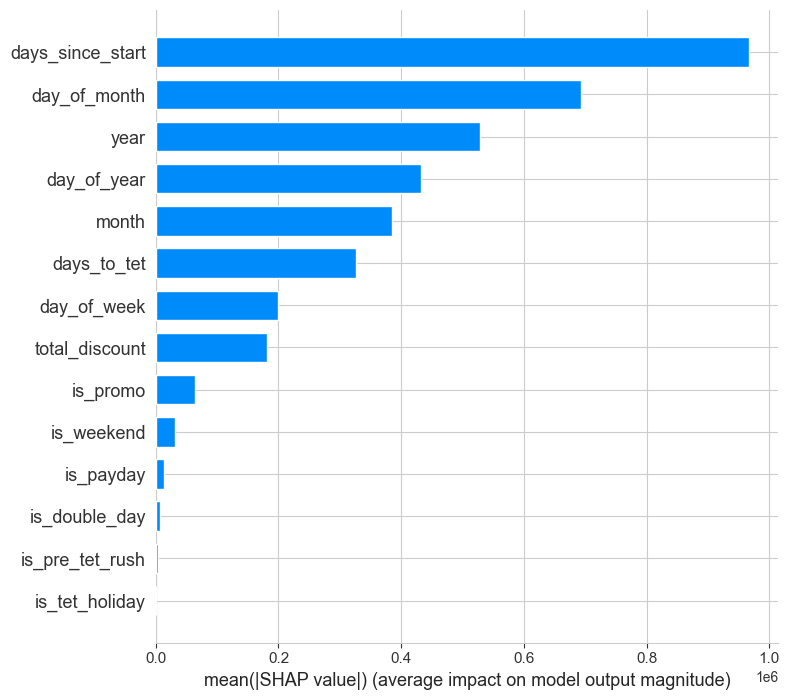

In [8]:
plot_shap_bar(model, val_result, features)

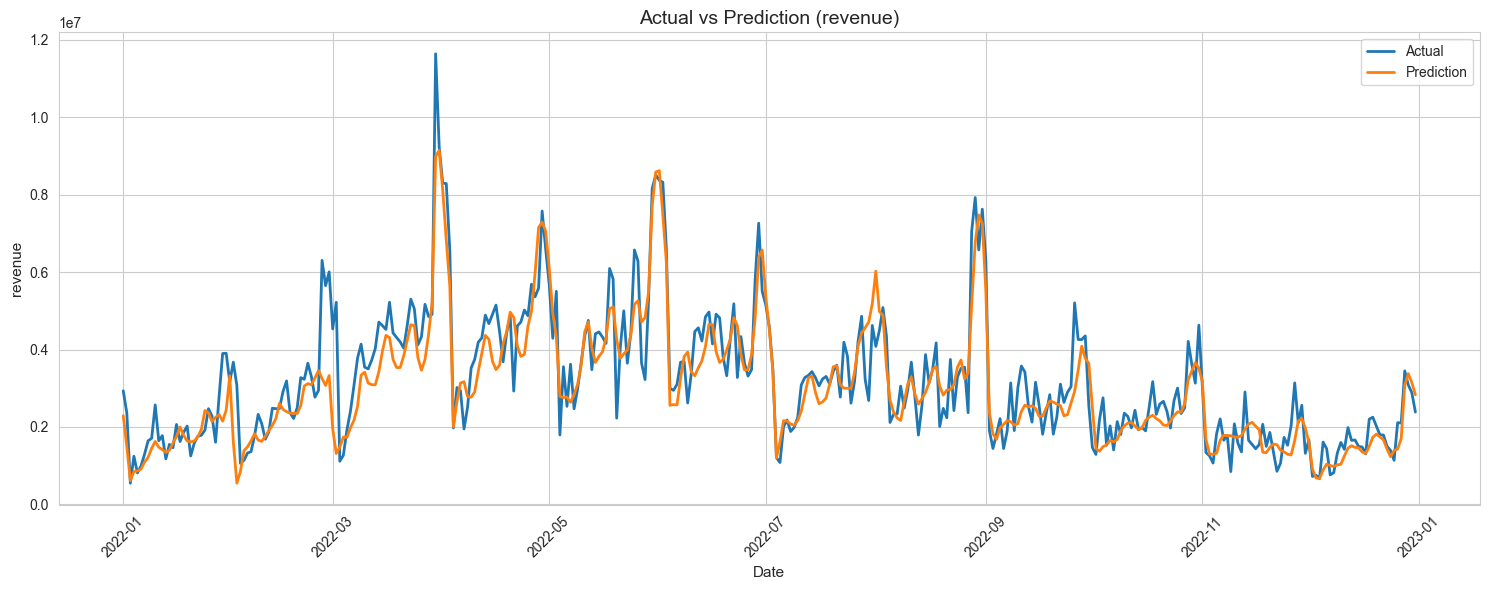

In [9]:
plot_prediction_vs_actual(val_result, target = 'revenue')

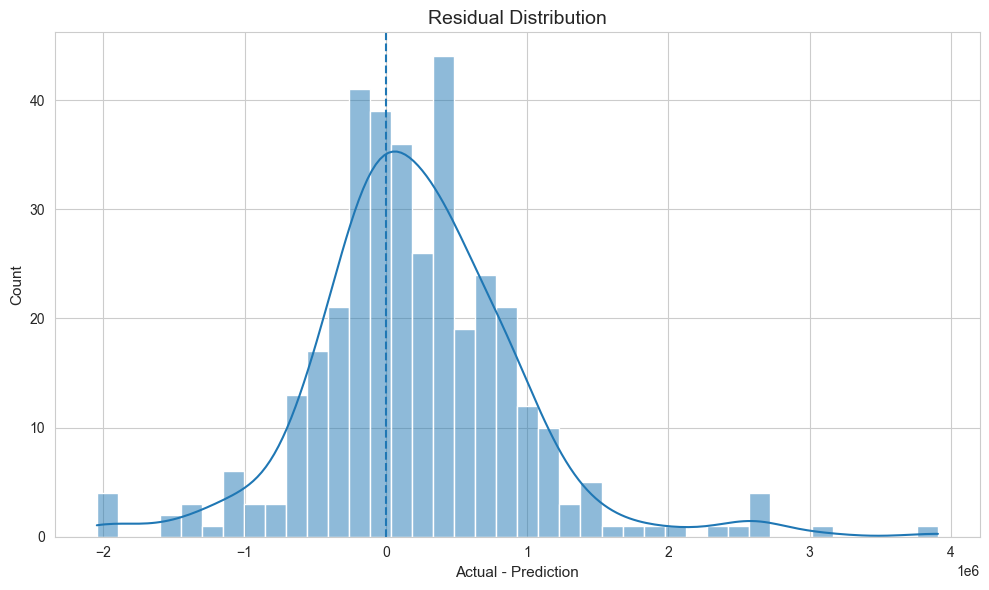

In [10]:
plot_residuals(val_result, target = 'revenue')